# практика оптимизации, алгоритм Нелдера-Мида

In [1]:
# тестовая функция розенброка
import numpy as np

def rosenbrock(x):
   """
   Функция вычисляет значение функции Розенброка для заданного вектора x.

   Параметры:
   x (numpy.ndarray): Вектор входных значений.

   Возвращает:
   float: Значение функции Розенброка для вектора x.
   """
   return np.sum(100.0 * (x[1:] - x[:-1]**2.0)**2.0 + (1 - x[:-1])**2.0, axis=0)




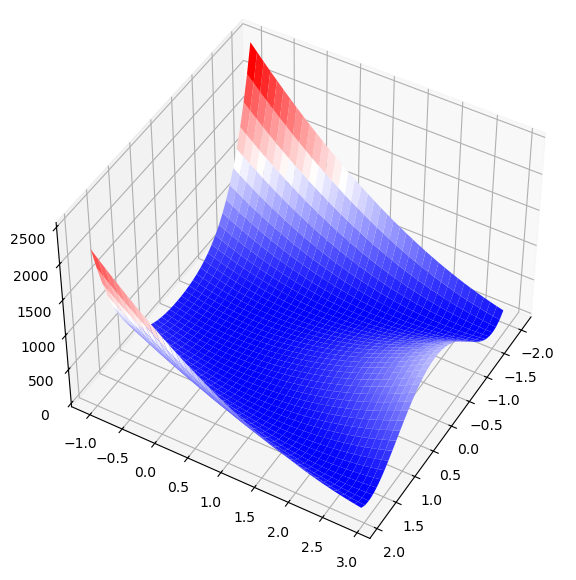

In [5]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.ticker import LinearLocator, FormatStrFormatter


fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.view_init(45, 30)

X = np.arange(-2, 2, 0.1)
Y = np.arange(-1, 3, 0.1)
X, Y = np.meshgrid(X, Y)
Z = rosenbrock(np.array([X, Y]))

surf = ax.plot_surface(X, Y, Z, cmap='bwr')
plt.show()

In [16]:
from scipy.optimize import minimize

# Начальная точка
x0 = np.array([1.2,0.7, 2.1])

# Оптимизация с использованием алгоритма Нелдера-Мида
# указываю функцию, начальную точку, метод оптимизации и в options указываю точность и вывод информации
res = minimize(rosenbrock, x0, method='Nelder-Mead', options={'xtol': 1e-8, 'disp': True})


Optimization terminated successfully.
         Current function value: 0.000000
         Iterations: 83
         Function evaluations: 149


/tmp/ipykernel_13549/4073098480.py:8: OptimizeWarning: Unknown solver options: xtol
  res = minimize(rosenbrock, x0, method='Nelder-Mead', options={'xtol': 1e-8, 'disp': True})


In [18]:
print(res)
print(res.x)
print(res.fun)
print(res.nit)
print(res.nfev)
print(res.status)
print(res.message)


       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 5.999640101883713e-09
             x: [ 1.000e+00  1.000e+00  1.000e+00]
           nit: 83
          nfev: 149
 final_simplex: (array([[ 1.000e+00,  1.000e+00,  1.000e+00],
                       [ 1.000e+00,  1.000e+00,  1.000e+00],
                       [ 1.000e+00,  1.000e+00,  1.000e+00],
                       [ 1.000e+00,  1.000e+00,  1.000e+00]]), array([ 6.000e-09,  6.926e-09,  8.971e-09,  2.196e-08]))
[1.00001005 1.00002169 1.00003618]
5.999640101883713e-09
83
149
0
Optimization terminated successfully.


In [27]:
# случайная точка начальная
x0 = np.random.uniform(low=0, high=2,size=(6,))
x0

array([1.12328419, 0.25707126, 1.96830515, 0.63592938, 0.80962909,
       1.17656115])

In [28]:
res = minimize(rosenbrock, x0, method='Nelder-Mead', options={'xtol': 1e-8, 'disp': True})


Optimization terminated successfully.
         Current function value: 0.000000
         Iterations: 612
         Function evaluations: 950


/tmp/ipykernel_13549/2940378812.py:1: OptimizeWarning: Unknown solver options: xtol
  res = minimize(rosenbrock, x0, method='Nelder-Mead', options={'xtol': 1e-8, 'disp': True})


# предположим что хочу устреднить результаты по различным начальным точкам

In [29]:
itList = []
resList = []

In [30]:
for kk in range(100):
    x0 = np.random.uniform(low=0, high=2,size=(4,))
    res = minimize(rosenbrock, x0, method='Nelder-Mead', options={'xtol': 1e-8, 'disp': False})
    itList.append(res.nit)
    resList.append(rosenbrock(res.x))



/tmp/ipykernel_13549/412267641.py:3: OptimizeWarning: Unknown solver options: xtol
  res = minimize(rosenbrock, x0, method='Nelder-Mead', options={'xtol': 1e-8, 'disp': False})


In [32]:
itList

[169,
 214,
 223,
 92,
 412,
 164,
 256,
 139,
 229,
 234,
 263,
 271,
 98,
 147,
 185,
 210,
 211,
 267,
 164,
 220,
 307,
 100,
 286,
 196,
 185,
 212,
 312,
 225,
 303,
 178,
 279,
 273,
 264,
 198,
 162,
 244,
 177,
 213,
 189,
 184,
 254,
 240,
 166,
 239,
 260,
 167,
 221,
 280,
 284,
 368,
 288,
 258,
 230,
 184,
 291,
 422,
 224,
 194,
 261,
 327,
 303,
 345,
 194,
 260,
 100,
 272,
 322,
 195,
 109,
 442,
 180,
 212,
 234,
 373,
 220,
 294,
 266,
 367,
 270,
 143,
 384,
 292,
 84,
 213,
 136,
 207,
 149,
 173,
 272,
 305,
 165,
 230,
 328,
 172,
 389,
 235,
 198,
 247,
 220,
 216]

In [34]:
np.mean(resList) # в какой то из 100 разов функция не нашла искомый оптимум

0.07519152536635701

In [35]:
# в какой момент это случилось
np.max(resList)

3.705074523281863

In [38]:
# сколько алгоритм работал в худшем случае и лучшем случае
print(np.min(itList))
print(np.max(itList))





84
442
